In [282]:
import math
from dataclasses import dataclass
from typing import Tuple, Optional, List

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from PIL import Image
import numpy as np
from tqdm import tqdm

In [283]:
@dataclass
class CFG:
    # Data
    data_root: str = "./data"
    img_size: int = 256
    batch_size: int = 1
    num_workers: int = 2

    # Model
    latent_channels: int = 4
    vae_channels: Tuple[int, ...] = (128, 256, 512, 512)
    vae_blocks: int = 2

    # Significantly reduced UNet size for T4 GPU memory limits
    unet_channels: Tuple[int, ...] = (128, 256, 512, 512)
    unet_mid_channels: int = 512
    unet_num_res_blocks: int = 2
    unet_attention_levels: Tuple[int, ...] = (2, 3)
    cross_attention_dim: int = 512
    num_attention_heads: int = 4

    # Diffusion
    num_train_timesteps: int = 1000
    beta_start: float = 0.00085
    beta_end: float = 0.012

    # Training
    learning_rate: float = 1e-4
    num_epochs: int = 5
    guidance_scale: float = 7.5

    # CLIP
    clip_model_name: str = "openai/clip-vit-base-patch32"

    # Device
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    # Output
    output_path: str = "./output"

In [284]:
class CelebAWithCaption(Dataset):
    """
    Wrap torchvision.datasets.CelebA to return (image, caption)
    using simple generic captions.
    """

    def __init__(self, root: str, split: str, img_size: int):
        # base CelebA dataset (CIFAR10-style)
        transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])

        self.base = datasets.CelebA(
            root=root,
            split=split,       # "train", "valid", "test"
            target_type="attr",
            download=True,
            transform=transform,
        )

        self.captions = [
            "a photo of a person",
            "a portrait of a person",
            "a face of a person",
        ]

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, _ = self.base[idx]                   # we ignore attributes
        caption = self.captions[idx % len(self.captions)]
        return img, caption


In [285]:
class ResBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, temb_ch: Optional[int] = None):
        super().__init__()
        self.norm1 = nn.GroupNorm(32, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)

        if temb_ch is not None:
            self.temb_proj = nn.Sequential(nn.SiLU(), nn.Linear(temb_ch, out_ch))
        else:
            self.temb_proj = None

        self.norm2 = nn.GroupNorm(32, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, temb=None):
        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)

        if temb is not None and self.temb_proj is not None:
            h = h + self.temb_proj(temb)[:, :, None, None]

        h = self.norm2(h)
        h = F.silu(h)
        h = self.conv2(h)
        return h + self.skip(x)


In [286]:
class Downsample(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, stride=2, padding=0)

    def forward(self, x):
        x = F.pad(x, (0, 1, 0, 1), mode="constant", value=0)
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1)

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        return self.conv(x)

In [287]:
class VAEEncoder(nn.Module):
    def __init__(self, in_ch: int, channels, latent_ch: int, num_blocks: int):
        super().__init__()
        self.conv_in = nn.Conv2d(in_ch, channels[0], 3, padding=1)

        blocks = []
        in_c = channels[0]
        for i, out_c in enumerate(channels):
            for _ in range(num_blocks):
                blocks.append(ResBlock(in_c, out_c))
                in_c = out_c
            if i < len(channels) - 1:
                blocks.append(Downsample(in_c, out_c))
        self.blocks = nn.ModuleList(blocks)

        self.mid = nn.ModuleList([ResBlock(in_c, in_c), ResBlock(in_c, in_c)])
        self.norm_out = nn.GroupNorm(32, in_c)
        self.conv_out = nn.Conv2d(in_c, 2 * latent_ch, 3, padding=1)

    def forward(self, x):
        h = self.conv_in(x)
        for block in self.blocks:
            h = block(h)
        for block in self.mid:
            h = block(h)
        h = self.norm_out(h)
        h = F.silu(h)
        return self.conv_out(h)

In [288]:
class VAEDecoder(nn.Module):
    def __init__(self, out_ch: int, channels, latent_ch: int, num_blocks: int):
        super().__init__()
        self.conv_in = nn.Conv2d(latent_ch, channels[-1], 3, padding=1)

        in_c = channels[-1]
        self.mid = nn.ModuleList([ResBlock(in_c, in_c), ResBlock(in_c, in_c)])

        blocks = []
        for i, out_c in enumerate(reversed(channels)):
            for _ in range(num_blocks + 1):
                blocks.append(ResBlock(in_c, out_c))
                in_c = out_c
            if i < len(channels) - 1:
                blocks.append(Upsample(in_c, in_c))
        self.blocks = nn.ModuleList(blocks)

        self.norm_out = nn.GroupNorm(32, in_c)
        self.conv_out = nn.Conv2d(in_c, out_ch, 3, padding=1)

    def forward(self, x):
        h = self.conv_in(x)
        for block in self.mid:
            h = block(h)
        for block in self.blocks:
            h = block(h)
        h = self.norm_out(h)
        h = F.silu(h)
        return self.conv_out(h)

In [289]:
class VAE(nn.Module):
    def __init__(self, cfg: CFG):
        super().__init__()
        self.encoder = VAEEncoder(
            in_ch=3,
            channels=cfg.vae_channels,
            latent_ch=cfg.latent_channels,
            num_blocks=cfg.vae_blocks,
        )
        self.decoder = VAEDecoder(
            out_ch=3,
            channels=cfg.vae_channels,
            latent_ch=cfg.latent_channels,
            num_blocks=cfg.vae_blocks,
        )
        self.scale = 0.18215

    def encode(self, x):
        moments = self.encoder(x)
        mean, logvar = torch.chunk(moments, 2, dim=1)
        logvar = torch.clamp(logvar, -30, 20)
        return mean, logvar

    def decode(self, z):
        return self.decoder(z / self.scale)

    def forward(self, x):
        mean, logvar = self.encode(x)
        z = mean + torch.exp(0.5 * logvar) * torch.randn_like(mean)
        x_recon = self.decode(z)
        kl = -0.5 * torch.mean(1 + logvar - mean.pow(2) - logvar.exp())
        return x_recon, kl


In [290]:
def get_timestep_embedding(t, dim, max_period=10000):
    half = dim // 2
    freqs = torch.exp(
        -math.log(max_period)
        * torch.arange(half, device=t.device, dtype=torch.float32)
        / half
    )
    args = t[:, None].float() * freqs[None, :]
    emb = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
    if dim % 2:
        emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=-1)
    return emb

In [291]:
class CrossAttention(nn.Module):
    def __init__(self, q_dim, ctx_dim, heads=8):
        super().__init__()
        self.heads = heads
        self.to_q = nn.Linear(q_dim, q_dim, bias=False)
        self.to_k = nn.Linear(ctx_dim, q_dim, bias=False)
        self.to_v = nn.Linear(ctx_dim, q_dim, bias=False)
        self.to_out = nn.Linear(q_dim, q_dim)
        self.norm_q = nn.LayerNorm(q_dim)
        self.norm_k = nn.LayerNorm(q_dim) # Changed from ctx_dim to q_dim

    def forward(self, x, ctx):
        # x is expected to be (B, C, H, W) from UNet
        b, c_x, h_x, w_x = x.shape

        # Reshape x from (B, C, H, W) to (B, H*W, C) for attention
        x_flat = x.permute(0, 2, 3, 1).reshape(b, h_x * w_x, c_x)

        q = self.norm_q(self.to_q(x_flat))
        k = self.norm_k(self.to_k(ctx))
        v = self.to_v(ctx)

        # Split into heads and transpose
        q = q.view(b, -1, self.heads, c_x // self.heads).transpose(1, 2)
        k = k.view(b, -1, self.heads, c_x // self.heads).transpose(1, 2)
        v = v.view(b, -1, self.heads, c_x // self.heads).transpose(1, 2)

        scale = 1.0 / math.sqrt(c_x // self.heads)
        attn = torch.softmax(q @ k.transpose(-2, -1) * scale, dim=-1)
        out = attn @ v

        # Combine heads and reshape back to (B, H*W, C)
        out = out.transpose(1, 2).reshape(b, h_x * w_x, c_x)
        out = self.to_out(out)

        # Reshape back to (B, C, H, W)
        out = out.reshape(b, h_x, w_x, c_x).permute(0, 3, 1, 2).contiguous()

        return out

In [292]:
class ResBlockUNet(nn.Module):
    def __init__(self, in_ch, out_ch, temb_ch):
        super().__init__()
        self.norm1 = nn.GroupNorm(32, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.temb_proj = nn.Sequential(nn.SiLU(), nn.Linear(temb_ch, out_ch))
        self.norm2 = nn.GroupNorm(32, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, temb):
        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)
        h = h + self.temb_proj(temb)[:, :, None, None]
        h = self.norm2(h)
        h = F.silu(h)
        h = self.conv2(h)
        return h + self.skip(x)


In [293]:
class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, temb_ch, num_res, has_attn, ctx_dim, heads):
        super().__init__()
        self.res = nn.ModuleList(
            [ResBlockUNet(in_ch if i == 0 else out_ch, out_ch, temb_ch) for i in range(num_res)]
        )
        self.attn = CrossAttention(out_ch, ctx_dim, heads) if has_attn else None
        self.down = nn.Conv2d(out_ch, out_ch, 3, stride=2, padding=1)

    def forward(self, x, temb, ctx=None):
        h = x
        for res in self.res:
            h = res(h, temb)
        if self.attn and ctx is not None:
            h = self.attn(h, ctx)
        return self.down(h)


In [294]:
class MidBlock(nn.Module):
    def __init__(self, ch, temb_ch, ctx_dim, heads):
        super().__init__()
        self.res1 = ResBlockUNet(ch, ch, temb_ch)
        self.attn = CrossAttention(ch, ctx_dim, heads)
        self.res2 = ResBlockUNet(ch, ch, temb_ch)

    def forward(self, x, temb, ctx):
        h = self.res1(x, temb)
        h = self.attn(h, ctx)
        return self.res2(h, temb)

In [295]:
class UpBlock(nn.Module):
    def __init__(self, in_ch_current_h, in_ch_skip_connection, out_ch, temb_ch, num_res, has_attn, ctx_dim, heads):
        super().__init__()
        # The first res block takes the concatenated features (in_ch_current_h + in_ch_skip_connection)
        # Subsequent res blocks take the output_ch
        self.res = nn.ModuleList(
            [
                ResBlockUNet(
                    in_ch_current_h + in_ch_skip_connection if i == 0 else out_ch,
                    out_ch,
                    temb_ch
                )
                for i in range(num_res + 1)
            ]
        )
        self.attn = CrossAttention(out_ch, ctx_dim, heads) if has_attn else None
        self.up = nn.Conv2d(out_ch, out_ch, 3, padding=1)

    def forward(self, x, temb, skip, ctx=None):
        h = x
        for i, res in enumerate(self.res):
            # For the first res block, concatenate x and skip
            h = res(torch.cat([h, skip], dim=1) if i == 0 else h, temb)
        if self.attn and ctx is not None:
            h = self.attn(h, ctx)
        return F.interpolate(self.up(h), scale_factor=2, mode="nearest")

In [296]:
class UNet2D(nn.Module):
    def __init__(self, cfg: CFG):
        super().__init__()
        self.time_emb = nn.Sequential(
            nn.Linear(cfg.latent_channels, cfg.unet_channels[0]),
            nn.SiLU(),
            nn.Linear(cfg.unet_channels[0], cfg.unet_channels[0]),
        )
        self.conv_in = nn.Conv2d(cfg.latent_channels, cfg.unet_channels[0], 3, padding=1)

        # Down
        self.down = nn.ModuleList()
        in_ch = cfg.unet_channels[0]
        for i, out_ch in enumerate(cfg.unet_channels):
            self.down.append(
                DownBlock(
                    in_ch,
                    out_ch,
                    cfg.unet_channels[0],
                    cfg.unet_num_res_blocks,
                    i in cfg.unet_attention_levels,
                    cfg.cross_attention_dim,
                    cfg.num_attention_heads,
                )
            )
            in_ch = out_ch

        # Mid
        self.mid = MidBlock(
            cfg.unet_mid_channels,
            cfg.unet_channels[0],
            cfg.cross_attention_dim,
            cfg.num_attention_heads,
        )

        # Up
        self.up = nn.ModuleList()
        ch_rev = list(reversed(cfg.unet_channels))
        # Track the input channels for the current 'h' (output of previous up/mid block)
        in_ch_for_h = cfg.unet_mid_channels # For the first UpBlock, 'h' comes from MidBlock

        for i, out_ch_upblock in enumerate(ch_rev):
            # out_ch_upblock is the 'out_ch' parameter for UpBlock,
            # and also the channels of the skip connection from the corresponding down block
            self.up.append(
                UpBlock(
                    in_ch_current_h=in_ch_for_h, # Channels of 'h' (output of previous layer)
                    in_ch_skip_connection=out_ch_upblock, # Channels of the skip connection (from down block)
                    out_ch=out_ch_upblock, # The desired output channels for this UpBlock
                    temb_ch=cfg.unet_channels[0],
                    num_res=cfg.unet_num_res_blocks,
                    has_attn=(len(cfg.unet_channels) - 1 - i) in cfg.unet_attention_levels,
                    ctx_dim=cfg.cross_attention_dim,
                    heads=cfg.num_attention_heads,
                )
            )
            in_ch_for_h = out_ch_upblock # The output of this UpBlock stage becomes the 'h' for the next UpBlock

        self.norm_out = nn.GroupNorm(32, cfg.unet_channels[0])
        self.conv_out = nn.Conv2d(cfg.unet_channels[0], cfg.latent_channels, 3, padding=1)

    def forward(self, x, t, ctx):
        temb = self.time_emb(get_timestep_embedding(t, self.time_emb[0].in_features))
        h = self.conv_in(x)

        skips = [h]
        for down in self.down:
            h = down(h, temb, ctx)
            skips.append(h)

        h = self.mid(h, temb, ctx)

        skips = list(reversed(skips))
        for i, up in enumerate(self.up):
            # h is input_ch_current_h for the UpBlock
            # skips[i] is input_ch_skip_connection for the UpBlock
            h = up(h, temb, skips[i], ctx)

        h = self.norm_out(h)
        h = F.silu(h)
        return self.conv_out(h)

In [297]:
class DDPMScheduler:
    def __init__(self, timesteps=1000, beta_start=0.00085, beta_end=0.012, device='cpu'):
        self.timesteps = timesteps
        self.betas = torch.linspace(beta_start, beta_end, timesteps, device=device)
        self.alphas = 1.0 - self.betas
        self.alpha_cumprod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_cumprod = torch.sqrt(self.alpha_cumprod)
        self.sqrt_one_minus_alpha = torch.sqrt(1.0 - self.alpha_cumprod)

    def add_noise(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        return (
            self.sqrt_alpha_cumprod[t].view(-1, 1, 1, 1) * x0
            + self.sqrt_one_minus_alpha[t].view(-1, 1, 1, 1) * noise
        )

    def step(self, noise_pred, t, x_t):
        # t is a batch of timesteps
        alpha_t = self.alphas[t].view(-1, 1, 1, 1)
        alpha_cumprod_t = self.alpha_cumprod[t].view(-1, 1, 1, 1)

        # Correctly handle prev_alpha for the whole batch
        alpha_cumprod_prev = torch.where(
            t > 0,
            self.alpha_cumprod[t - 1] if any(t > 0) else torch.tensor(1.0, device=t.device),
            torch.tensor(1.0, device=t.device)
        ).view(-1, 1, 1, 1)

        pred_x0 = (x_t - noise_pred * torch.sqrt(1 - alpha_cumprod_t)) / torch.sqrt(
            alpha_cumprod_t
        )
        pred_x0 = torch.clamp(pred_x0, -1, 1)

        coef1 = torch.sqrt(alpha_cumprod_prev) * (1 - alpha_t) / (1 - alpha_cumprod_t)
        coef2 = torch.sqrt(alpha_t) * (1 - alpha_cumprod_prev) / (1 - alpha_cumprod_t)

        x_prev = coef1 * x_t + coef2 * pred_x0

        # Mask for adding noise (only if t > 0)
        if t[0] > 0:
            noise = torch.randn_like(x_prev)
            x_prev = x_prev + torch.sqrt(1 - alpha_cumprod_prev) * noise

        return x_prev

In [298]:
class CLIPEncoder(nn.Module):
    def __init__(self, model_name="openai/clip-vit-base-patch32"):
        super().__init__()
        from transformers import CLIPProcessor, CLIPModel

        self.model = CLIPModel.from_pretrained(model_name)
        self.processor = CLIPProcessor.from_pretrained(model_name)
        self.model.requires_grad_(False)
        self.model.eval()

    def forward(self, text: List[str], device: torch.device):
        # Ensure consistent sequence length (77) by using padding="max_length"
        inputs = self.processor(
            text=text,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=77,
        ).to(device)
        with torch.no_grad():
            outputs = self.model.text_model(**inputs)
        return outputs.last_hidden_state  # [B, 77, 512]

In [299]:
class StableDiffusionPipeline:
    def __init__(self, cfg: CFG):
        self.cfg = cfg
        self.device = torch.device(cfg.device)

        self.vae = VAE(cfg).to(self.device)
        self.unet = UNet2D(cfg).to(self.device)
        self.clip = CLIPEncoder(cfg.clip_model_name).to(self.device)
        self.scheduler = DDPMScheduler(
            cfg.num_train_timesteps, cfg.beta_start, cfg.beta_end, device=self.device # Pass device to scheduler
        )

        self.vae.requires_grad_(False)
        self.clip.requires_grad_(False)

    def encode_text(self, text: List[str]):
        return self.clip(text, self.device)

    def encode_image(self, x):
        with torch.no_grad():
            mean, _ = self.vae.encode(x)
            return mean * self.vae.scale

    def decode_image(self, z):
        with torch.no_grad():
            return self.vae.decode(z)

In [300]:
@torch.no_grad()
def generate(
        self,
        prompt: str,
        negative_prompt: str = "",
        height: int = 256,
        width: int = 256,
        num_steps: int = 50,
        guidance_scale: float = 7.5,
        seed: Optional[int] = None,
    ) -> Image.Image:
        if seed is not None:
            torch.manual_seed(seed)
            np.random.seed(seed)

        ctx = self.encode_text([prompt])
        if guidance_scale > 1.0:
            uncond_ctx = self.encode_text([negative_prompt if negative_prompt else ""])
            ctx = torch.cat([uncond_ctx, ctx], dim=0)

        z = torch.randn(
            1, self.cfg.latent_channels, height // 8, width // 8, device=self.device
        )
        if guidance_scale > 1.0:
            z = torch.cat([z, z], dim=0)

        timesteps = torch.linspace(
            self.cfg.num_train_timesteps - 1,
            0,
            num_steps,
            dtype=torch.long,
            device=self.device,
        )

        for t in tqdm(timesteps, desc="Sampling"):
            t_batch = torch.tensor([t], device=self.device).expand(z.shape[0])
            noise_pred = self.unet(z, t_batch, ctx)

            if guidance_scale > 1.0:
                noise_uncond, noise_cond = noise_pred.chunk(2)
                noise_pred = noise_uncond + guidance_scale * (
                    noise_cond - noise_uncond
                )

            z = self.scheduler.step(noise_pred, t_batch, z)

        if guidance_scale > 1.0:
            z = z[:1]

        img = self.decode_image(z)
        img = (img / 2 + 0.5).clamp(0, 1)[0].permute(1, 2, 0).cpu().numpy()
        img = (img * 255).astype(np.uint8)
        return Image.fromarray(img)


In [301]:
def train(cfg: CFG, train_loader: DataLoader) -> StableDiffusionPipeline:
    import os

    os.makedirs(cfg.output_path, exist_ok=True)

    pipeline = StableDiffusionPipeline(cfg)
    pipeline.clip.eval()
    pipeline.vae.eval()

    optimizer = torch.optim.AdamW(
        pipeline.unet.parameters(),
        lr=cfg.learning_rate,
        betas=(0.9, 0.999),
        weight_decay=1e-2,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cfg.num_epochs * len(train_loader)
    )

    for epoch in range(cfg.num_epochs):
        pipeline.unet.train()
        total_loss = 0.0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.num_epochs}")
        for images, captions in pbar:
            images = images.to(cfg.device)

            with torch.no_grad():
                ctx = pipeline.encode_text(captions)
                latent = pipeline.encode_image(images)

            t = torch.randint(
                0,
                cfg.num_train_timesteps,
                (cfg.batch_size,),
                device=cfg.device,
                dtype=torch.long,
            )
            noise = torch.randn_like(latent)
            noisy = pipeline.scheduler.add_noise(latent, t, noise)

            if cfg.guidance_scale > 1.0:
                ctx = torch.cat([torch.zeros_like(ctx), ctx], dim=0)
                noisy = torch.cat([noisy, noisy], dim=0)
                t = torch.cat([t, t], dim=0)

            pred = pipeline.unet(noisy, t, ctx)
            if cfg.guidance_scale > 1.0:
                pred = pred[cfg.batch_size:]

            loss = F.mse_loss(pred, noise)
            loss.backward()
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

            total_loss += loss.item()
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1} - Avg Loss: {avg_loss:.4f}")

    return pipeline

In [302]:
cfg = CFG()

In [303]:
full_train_dataset = CelebAWithCaption(
    root=cfg.data_root,
    split="train",
    img_size=cfg.img_size,
)

# Truncate dataset to 1000 samples to save memory and time
indices = list(range(1000))
train_dataset = torch.utils.data.Subset(full_train_dataset, indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=True,
)

print(f"Original dataset size: {len(full_train_dataset)}")
print(f"Truncated dataset size: {len(train_dataset)}")

Original dataset size: 162770
Truncated dataset size: 1000


In [304]:
pipeline = train(cfg, train_loader)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Epoch 1/5: 100%|██████████| 1000/1000 [02:18<00:00,  7.22it/s, loss=0.1995]


Epoch 1 - Avg Loss: 0.3611


Epoch 2/5: 100%|██████████| 1000/1000 [02:22<00:00,  7.03it/s, loss=0.1509]


Epoch 2 - Avg Loss: 0.1762


...

Epoch 3 - Avg Loss: 0.1353


Epoch 4/5: 100%|██████████| 1000/1000 [02:22<00:00,  7.04it/s, loss=0.1298]


Epoch 4 - Avg Loss: 0.1182


Epoch 5/5: 100%|██████████| 1000/1000 [02:22<00:00,  7.00it/s, loss=0.0962]

Epoch 5 - Avg Loss: 0.1123


Sampling: 100%|██████████| 50/50 [00:00<00:00, 61.06it/s]


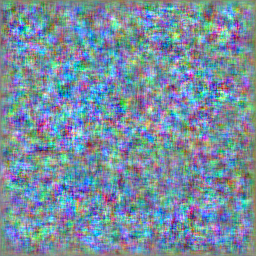

In [305]:
# Attach the generate function to the class so the instance can use it
StableDiffusionPipeline.generate = generate

img = pipeline.generate(
    prompt="a photo of a person with sunglasses",
    negative_prompt="blurry, low quality",
    num_steps=50,
    guidance_scale=7.5,
    seed=42,
)
img.save("sample_celeba_sd.png")
img